**Topic: Real-Time Quality Index(AQI)Analysis from Various Locations in India**

**Project Overview**

This project analyzes real-time air quality data collected from monitoring stations across different states and cities in India.
The objective is to understand pollution levels, identify areas with poor air quality, compare pollutants across locations, 
and support environmental monitoring and decision-making.

**1. Data Loading and Initial Overview**

In [17]:
import pandas as pd
import pandas as np
df=pd.read_csv("Downloads/Real time Air Quality Index from various locations.csv")

In [4]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",27-06-2026 20:00:00,26.987634,94.636574,PM2.5,15.0,37.0,25.0
1,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",27-06-2026 20:00:00,26.987634,94.636574,PM10,25.0,43.0,31.0
2,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",27-06-2026 20:00:00,26.987634,94.636574,OZONE,30.0,65.0,47.0
3,India,Bihar,Araria,"Kharahiya Basti, Araria - BSPCB",27-06-2026 20:00:00,26.146529,87.454184,PM2.5,40.0,190.0,87.0
4,India,Bihar,Araria,"Kharahiya Basti, Araria - BSPCB",27-06-2026 20:00:00,26.146529,87.454184,NH3,4.0,5.0,4.0


In [ ]:
Dataset Summary

1.Total records: 3,514
2.Total columns: 11
3.Coverage: India
4.States: 30
5.Cities: 266
6.Monitoring stations: 502

Columns

Country
State
City
Station
Last Update
Latitude
Longitude
Pollutant ID
Pollutant Minimum Value
Pollutant Maximum Value
Pollutant Average Value

In [5]:
#Number of rows and columns
print("shape of the data set:",df.shape)

shape of the data set: (3514, 11)


In [6]:
#Data types of coluns
print(df.dtypes)

country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3514 entries, 0 to 3513
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3514 non-null   object 
 1   state          3514 non-null   object 
 2   city           3514 non-null   object 
 3   station        3514 non-null   object 
 4   last_update    3514 non-null   object 
 5   latitude       3514 non-null   float64
 6   longitude      3514 non-null   float64
 7   pollutant_id   3514 non-null   object 
 8   pollutant_min  3197 non-null   float64
 9   pollutant_max  3197 non-null   float64
 10  pollutant_avg  3197 non-null   float64
dtypes: float64(5), object(6)
memory usage: 302.1+ KB


**2.Data Pre-processing**

In [8]:
# Check for missing values
print(df.isnull().sum())

country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    317
pollutant_max    317
pollutant_avg    317
dtype: int64


In [9]:
# Check duplicates
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [10]:
# Show duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [country, state, city, station, last_update, latitude, longitude, pollutant_id, pollutant_min, pollutant_max, pollutant_avg]
Index: []


In [11]:
#correcting datatypes
df["country"]=df["country"].astype("category")
df["city"]=df["city"].astype("category")
df["last_update"]=pd.to_datetime(df["last_update"])

C:\Users\dell\AppData\Local\Temp\ipykernel_12472\340419285.py:4: UserWarning: Parsing dates in %d-%m-%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["last_update"]=pd.to_datetime(df["last_update"])


In [12]:
df.dtypes

country                category
state                    object
city                   category
station                  object
last_update      datetime64[ns]
latitude                float64
longitude               float64
pollutant_id             object
pollutant_min           float64
pollutant_max           float64
pollutant_avg           float64
dtype: object

In [37]:
#creating new columns
def category(aqi):
 if aqi<=50:
   return "Good"
 elif aqi<=100:
   return "Moderate"
 elif aqi<=150:
   return "Unhealthy for sensitive"
 elif aqi<=200:
   return "Unhealthy"
 elif aqi<=300:
   return "Very Unhealthy"
 else:
   return "Hazardous"
df ["AQI_Category"]=df["pollutant_avg" ].apply(category)


In [38]:
df.head()

,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg,AQI_Category
0,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",27-06-2026 20:00:00,26.987634,94.636574,PM2.5,15.0,37.0,25.0,Good
1,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",27-06-2026 20:00:00,26.987634,94.636574,PM10,25.0,43.0,31.0,Good
2,India,Assam,Sivasagar,"Girls College, Sivasagar - PCBA",27-06-2026 20:00:00,26.987634,94.636574,OZONE,30.0,65.0,47.0,Good
3,India,Bihar,Araria,"Kharahiya Basti, Araria - BSPCB",27-06-2026 20:00:00,26.146529,87.454184,PM2.5,40.0,190.0,87.0,Moderate
4,India,Bihar,Araria,"Kharahiya Basti, Araria - BSPCB",27-06-2026 20:00:00,26.146529,87.454184,NH3,4.0,5.0,4.0,Good


In [39]:
# Filter:- AQI= Good
df_Good = df[df['AQI_Category'] =='Good']
print(df_Good.shape)

(2452, 12)


In [17]:
# Aggregate:- Average of pollutant in states
avg_pollutant = df.groupby('state')['pollutant_avg'].mean()
print(avg_pollutant)

state
Andhra Pradesh       32.302083
Arunachal Pradesh    12.833333
Assam                32.921569
Bihar                35.082051
Chandigarh           34.357143
Chhattisgarh         20.328571
Delhi                54.841751
Gujarat              34.772059
Haryana              51.262295
Himachal Pradesh     48.000000
Jammu and Kashmir    18.733333
Jharkhand            52.090909
Karnataka            24.226667
Kerala               20.777778
Madhya Pradesh       33.969325
Maharashtra          23.637024
Meghalaya            28.555556
Mizoram               8.500000
Nagaland             15.500000
Odisha               30.477064
Puducherry           24.142857
Punjab               39.866667
Rajasthan            33.727829
Sikkim               15.142857
Tamil Nadu           31.054545
Telangana            26.352273
Tripura              30.285714
Uttar Pradesh        47.289406
Uttarakhand          33.000000
West Bengal          24.986928
Name: pollutant_avg, dtype: float64


**3.Exploratory Data Analysis(EDA)**

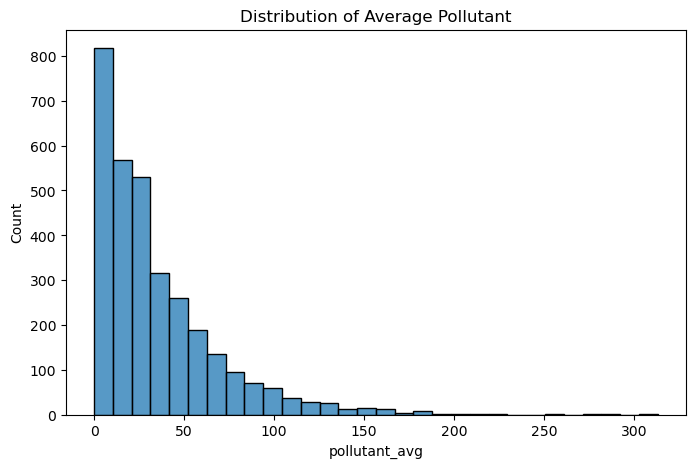

In [18]:
#Univariate Analyss
#Distribution of average pollutant

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df ["pollutant_avg"], bins =30)
plt.title("Distribution of Average Pollutant")
plt.show()

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")

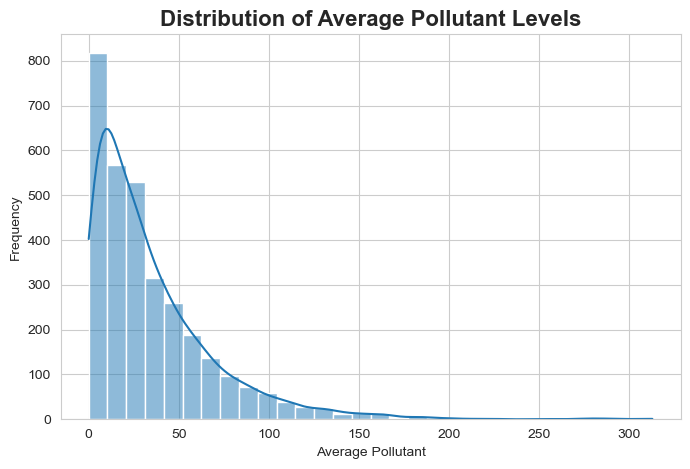

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df['pollutant_avg'], bins=30, kde=True)

plt.title("Distribution of Average Pollutant Levels", fontsize=16, fontweight='bold')
plt.xlabel("Average Pollutant")
plt.ylabel("Frequency")
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_12472\222500575.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_cities = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)


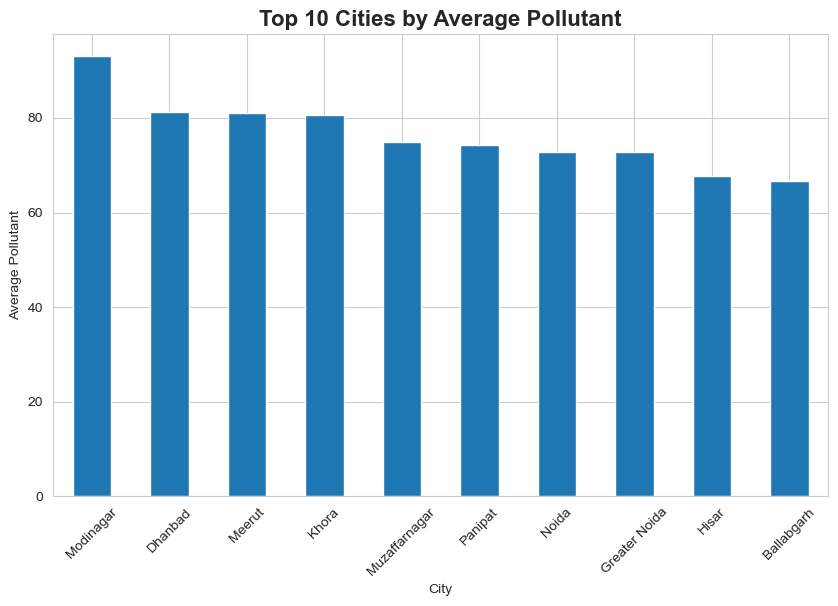

In [32]:
top_cities = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_cities.plot(kind='bar')

plt.title("Top 10 Cities by Average Pollutant", fontsize=16, fontweight='bold')
plt.xlabel("City")
plt.ylabel("Average Pollutant")
plt.xticks(rotation=45)
plt.show()

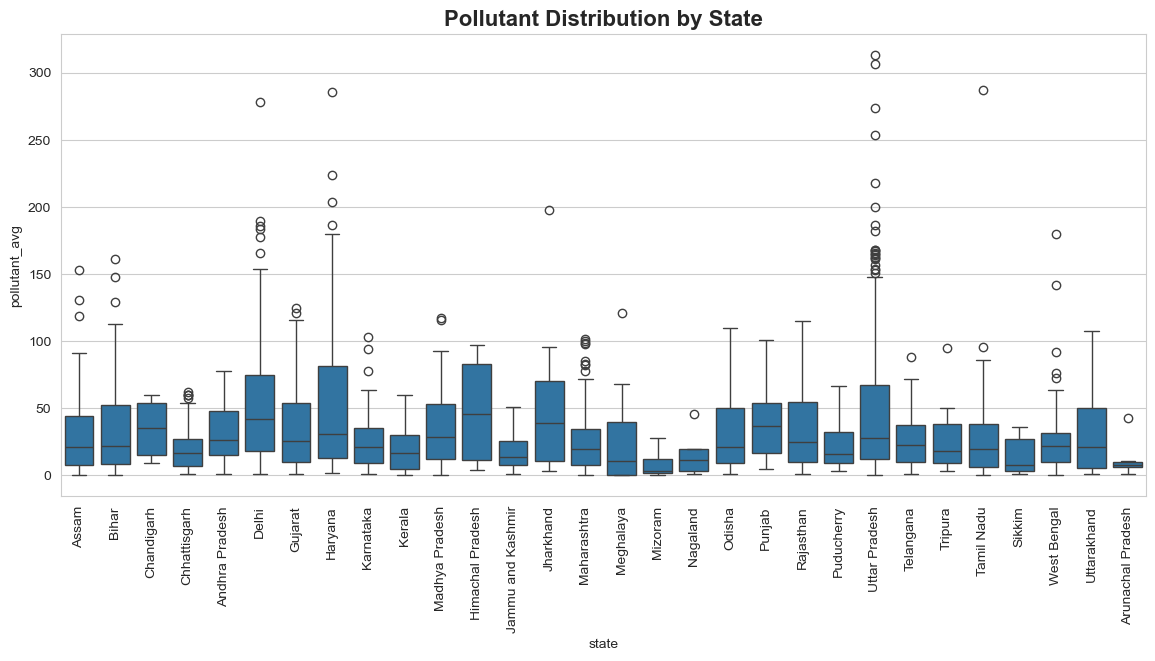

In [25]:
plt.figure(figsize=(14,6))
sns.boxplot(x='state', y='pollutant_avg', data=df)

plt.title("Pollutant Distribution by State", fontsize=16, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

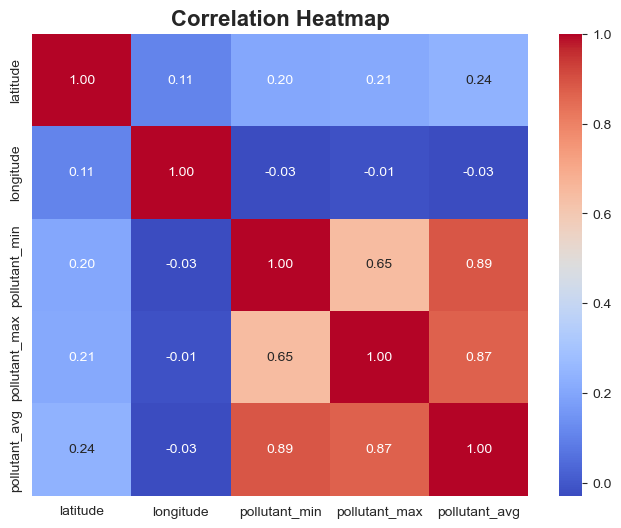

In [26]:
plt.figure(figsize=(8,6))

numeric = df.select_dtypes(include='number')

sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap", fontsize=16, fontweight='bold')
plt.show()

C:\Users\dell\AppData\Local\Temp\ipykernel_12472\2390659836.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top5 = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(5)


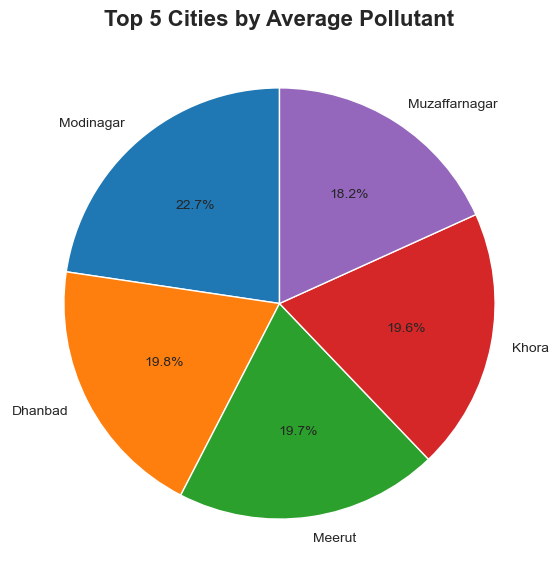

In [28]:
top5 = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(7,7))
plt.pie(top5, labels=top5.index, autopct='%1.1f%%', startangle=90)

plt.title("Top 5 Cities by Average Pollutant", fontsize=16, fontweight='bold')
plt.show()

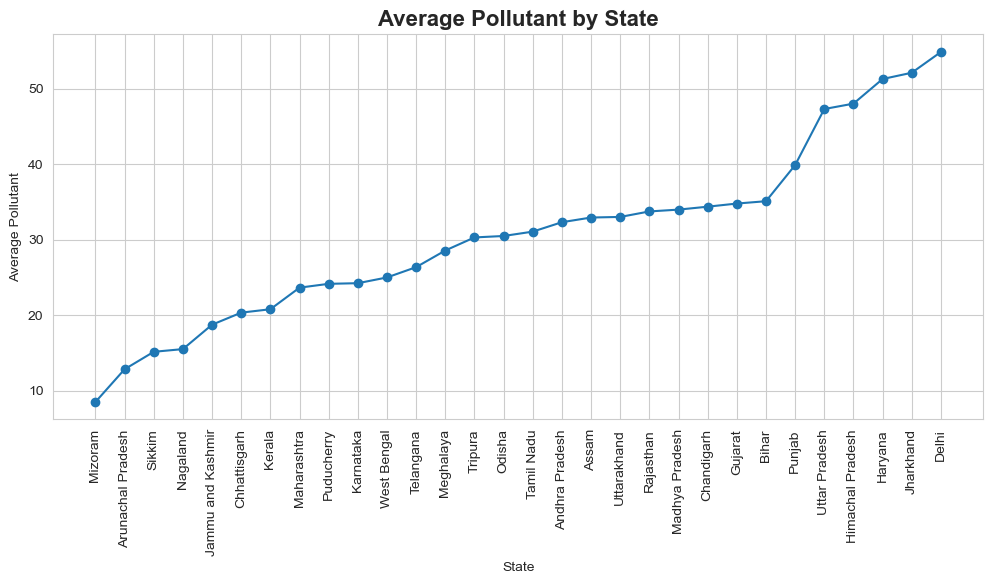

In [29]:
state_avg = df.groupby('state')['pollutant_avg'].mean().sort_values()

plt.figure(figsize=(12,5))
plt.plot(state_avg.index, state_avg.values, marker='o')

plt.title("Average Pollutant by State", fontsize=16, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Average Pollutant")
plt.xticks(rotation=90)
plt.show()

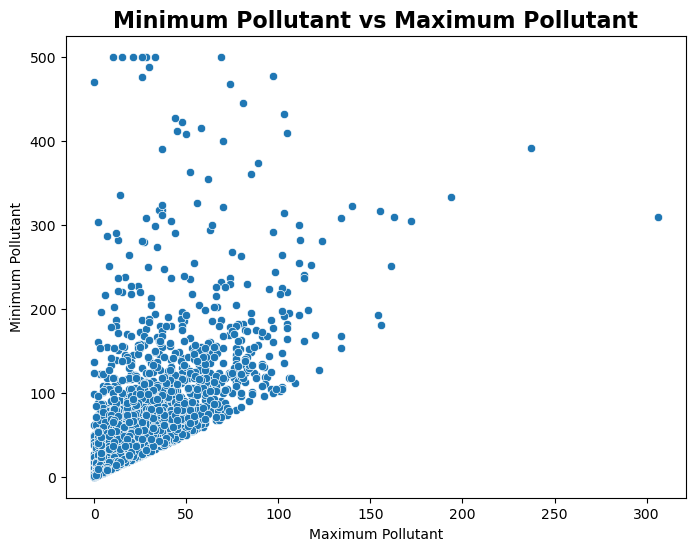

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='pollutant_min', y='pollutant_max')

plt.title("Minimum Pollutant vs Maximum Pollutant", fontsize=16, fontweight='bold')
plt.xlabel("Maximum Pollutant")
plt.ylabel("Minimum Pollutant")

plt.show()

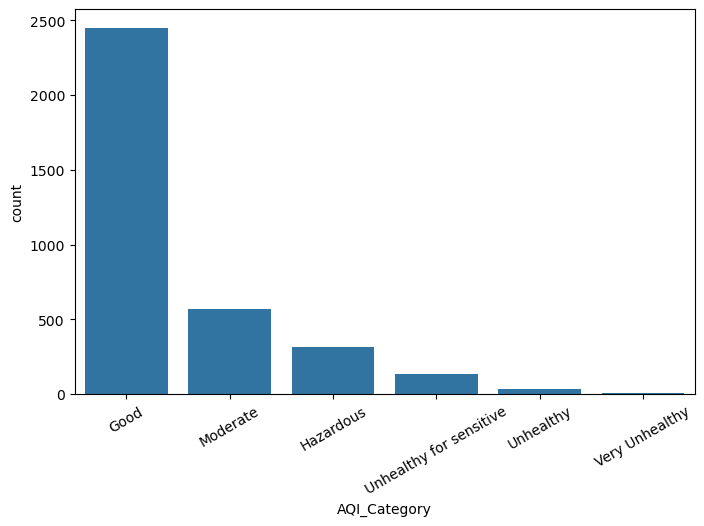

In [28]:
plt.figure(figsize=(8,5))

sns.countplot(x="AQI_Category",data=df)

plt.xticks(rotation=30)

plt.show()

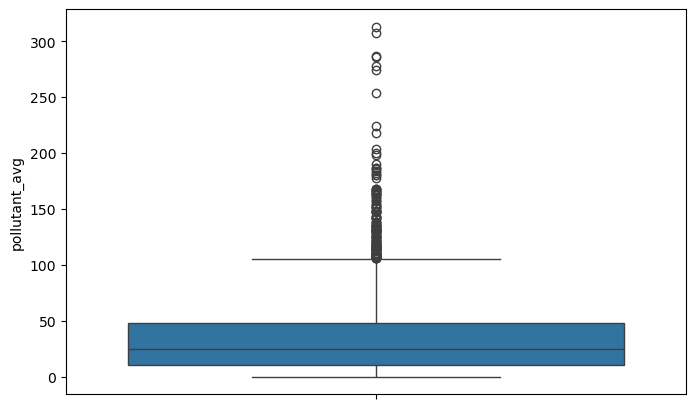

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["pollutant_avg"])
plt.show()

In [32]:
pivot=df.pivot_table(values="pollutant_avg",
                     index="state",
                     aggfunc="mean")
pivot.head()

,pollutant_avg
state,
Andhra Pradesh,32.302083
Arunachal Pradesh,12.833333
Assam,32.921569
Bihar,35.082051
Chandigarh,34.357143


**INSIGHTS**
                                

1. Dataset contains 3514 records and 11 columns.
2. Missing values and duplicate rows were handled.
3. AQI categories were created.
4. Some states recorded much higher average pollution levels.
5. Heatmap shows positive correlation between pollutant minimum, maximum and average.
6. Boxplot indicates presence of outliers.
7. Histogram shows the distribution of pollutant averages.
8. State-wise analysis identifies the most polluted locations.

**CONCLUSION**


The project successfully performed complete Exploratory Data Analysis on the Real-Time Air Quality Index dataset.
Data preprocessing improved data quality by removing missing values and duplicates. Statistical summaries, correlation analysis, and 
multiple visualizations revealed pollution trends across different states and cities.
The analysis helps identify highly polluted regions and provides useful insights for environmental monitoring and policy planning.